# Практическое занятие №2
## Амплитудная и фазовая модуляция: генерация, спектры, демодуляция и устойчивость к шумам

**Цель работы:**
- Научиться генерировать сигналы с амплитудной (АМ) и фазовой (ФМ) модуляцией.
- Исследовать спектральные характеристики модулированных сигналов.
- Изучить влияние индекса модуляции на спектр ФМ сигнала.
- Освоить демодуляцию АМ и ФМ с помощью преобразования Гильберта.
- Оценить устойчивость АМ и ФМ к амплитудному шуму на примере реального аудиосигнала.

**Необходимое ПО:** Python 3, библиотеки `numpy`, `matplotlib`, `scipy`, `ipywidgets`, `IPython.display`. Работа выполняется в Jupyter Notebook / Google Colab.

**Формат сдачи:** один Jupyter Notebook с кодом, графиками и текстовыми выводами. Имя файла: `2_Фамилия.ipynb`.

## Часть 1. Генерация и визуализация модулированных сигналов

### 1.1. Импорт библиотек и параметры

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
from scipy.signal import hilbert
import ipywidgets as widgets
from IPython.display import Audio, display

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

# Параметры дискретизации для демонстрации
fs = 10000                     # частота дискретизации (Гц)
T = 0.1                        # длительность сигнала (с)
t = np.linspace(0, T, int(fs*T), endpoint=False)

# Несущая
fc = 1000                      # частота несущей (Гц)
Ac = 1.0                       # амплитуда несущей

### 1.2. Модулирующий сигнал

В качестве модулирующего сигнала используйте сумму двух синусоид с частотами 100 Гц и 150 Гц, нормализованную к диапазону [-1, 1]. Постройте его график.

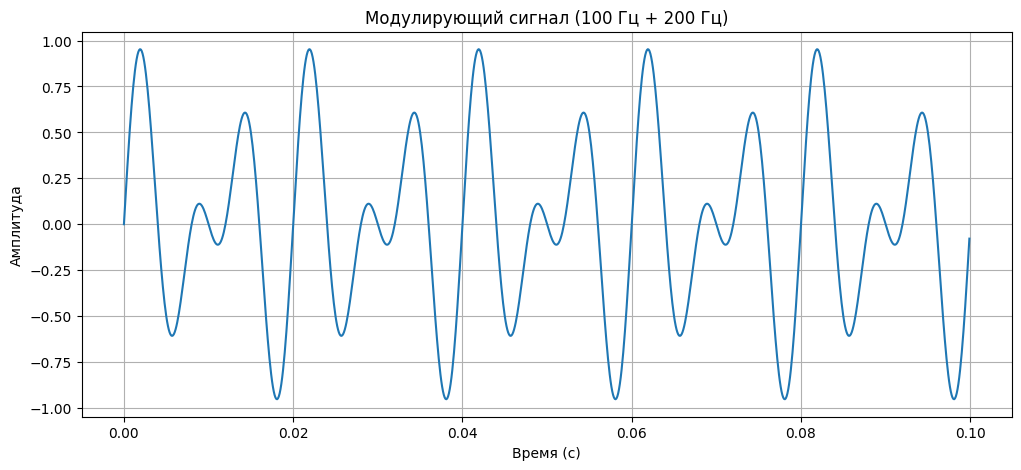

In [3]:
fm1 = 100
fm2 = 150
m_t = (np.sin(2*np.pi*fm1*t) + np.sin(2*np.pi*fm2*t)) / 2 # модулирующий сигнал - сумма двух синусоид со значениями в интервале [-1,1]

plt.figure()
plt.plot(t, m_t)
plt.title('Модулирующий сигнал (100 Гц + 200 Гц)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.show()

### 1.3. Амплитудная модуляция (АМ)

Формула АМ:
$$s_{AM}(t) = A_c [1 + a_{AM}\cdot m(t)] \cos(2\pi f_c t)
$$
Параметр $a_{AM}$ регулирует _глубину модуляции_, он не может быть больше 1 (при $a_{AM}>1$ и исходном сигнале $m(t)$, нормализованном на единицу, амплитуда результирующего сигнала в некоторые промежутки времени становится отрицательной).

In [4]:
a_am = 0.2
s_am = Ac * (1 + a_am * m_t) * np.cos(2*np.pi*fc*t)

### 1.4. Фазовая модуляция (ФМ)

Формула ФМ:
$$
s_{PM}(t) = A_c \cos(2\pi f_c t + \beta \cdot m(t)),
$$

где $\beta$ – индекс фазовой модуляции.

In [5]:
beta_pm = 5
s_pm = Ac * np.cos(2*np.pi*fc*t + beta_pm * m_t)

Постройте на одном графике модулирующий сигнал и оба модулированных сигнала (АМ, ФМ). Оси и графики должны быть подписаны.

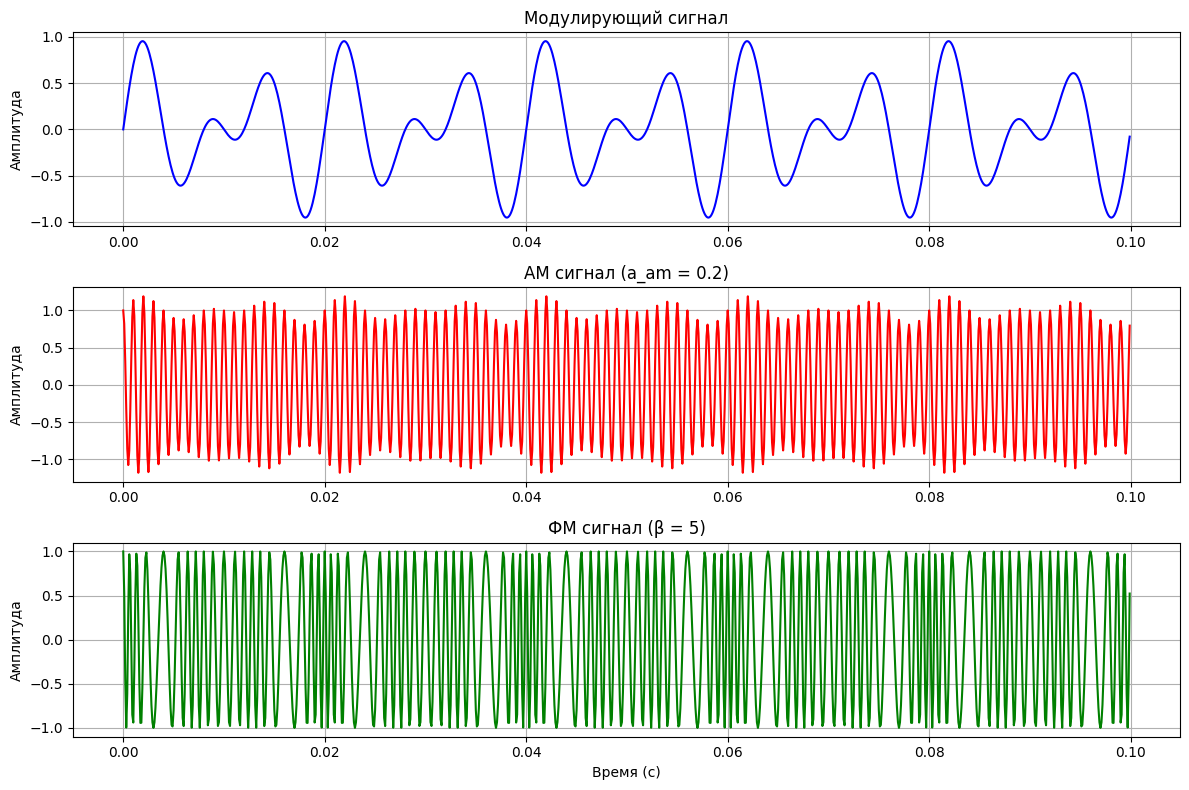

In [6]:
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(t, m_t, 'b-')
plt.title('Модулирующий сигнал')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(t, s_am, 'r-')
plt.title(f'АМ сигнал (a_am = {a_am})')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t, s_pm, 'g-')
plt.title(f'ФМ сигнал (β = {beta_pm})')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.tight_layout()
plt.show()

## Часть 2. Спектральный анализ модулированных сигналов

### 2.1. Функция построения амплитудного спектра
Реализуйте функцию построения амплитудного спектра ```plot_spectrum(s,fs,title)```
Значения аргументов:
* `s` - массив, содержащий значения сигнала
* `fs` - частота отсчётов сигнала
* `title` - заголовок графика, выводимый сверху

На графике по горизонтальной оси должна быть отложена частота в герцах, а по вертикальной - амплитуда гармоники. График должен строиться только для положительных значений частоты. Оси должны быть подписаны.

In [7]:
def plot_spectrum(s, fs, title):
    N = len(s)
    X = np.fft.fft(s)
    freq = np.fft.fftfreq(N, 1/fs)

    half = N // 2
    freq_pos = freq[:half]
    amplitude = np.abs(X[:half]) / half

    plt.figure()
    plt.stem(freq_pos, amplitude, basefmt=" ")
    plt.title(title)
    plt.xlabel('Частота (Гц)')
    plt.ylabel('Амплитуда')
    plt.grid(True)
    plt.xlim(0, 2000)
    plt.show()

### 2.2. Спектр АМ

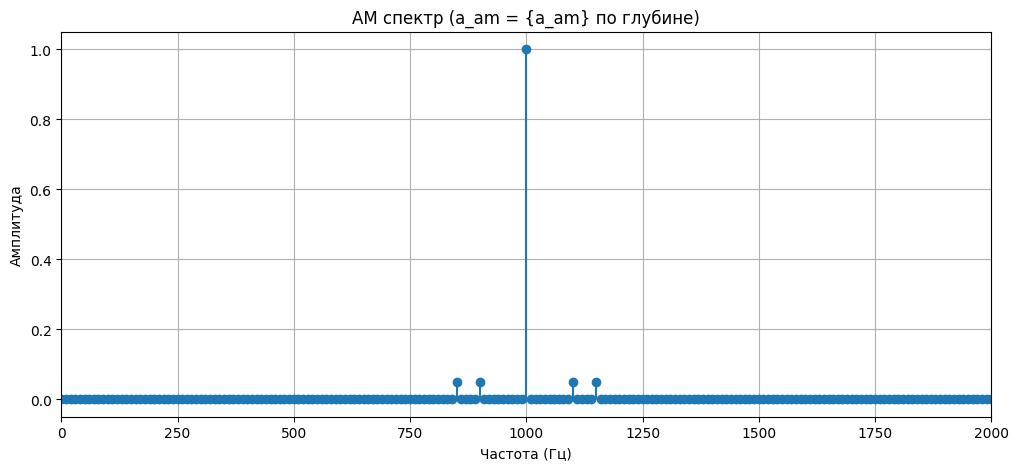

In [8]:
plot_spectrum(s_am, fs, 'АМ спектр (a_am = {a_am} по глубине)')

### 2.3. Спектр ФМ при разных индексах модуляции

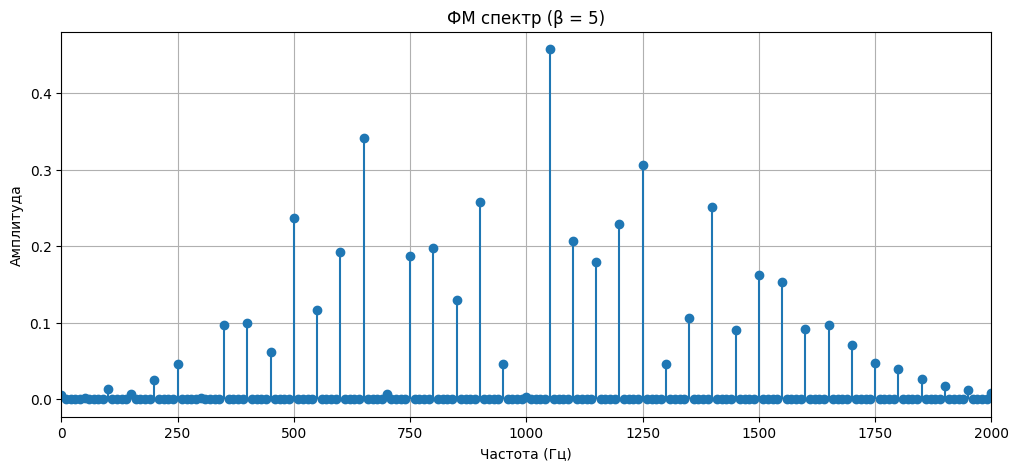

In [9]:
plot_spectrum(s_pm, fs, f'ФМ спектр (β = {beta_pm})')

Для ФМ постройте на одном графике спектры для разных индексов модуляции (например, β = 0.1, 0.3, 1, 2, 5, 10). Оси и графики должны быть подписаны.

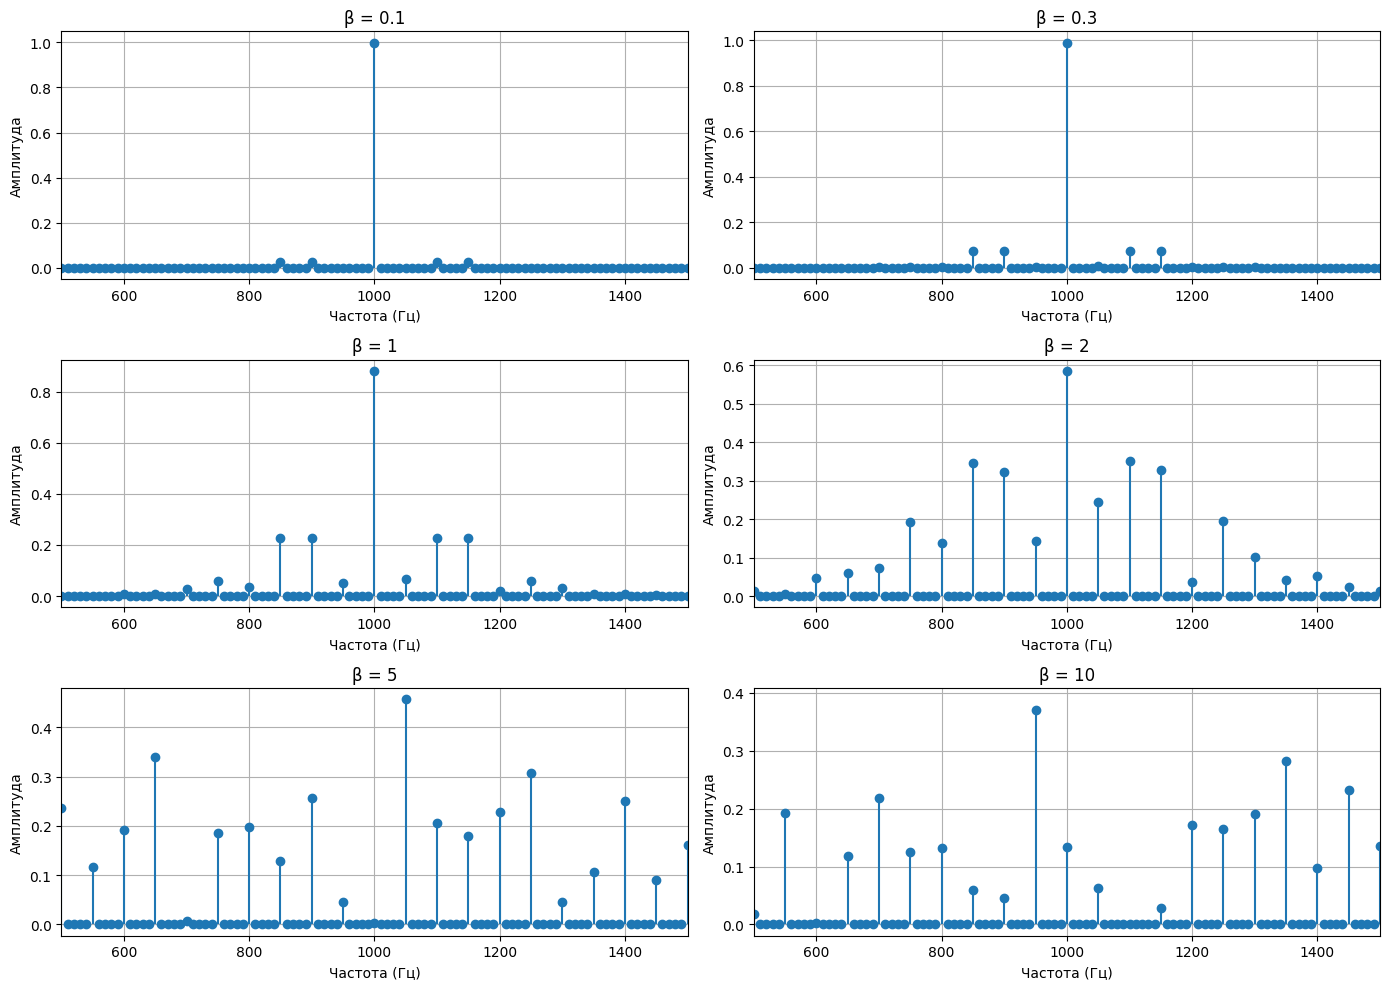

In [10]:
beta_values = [0.1, 0.3, 1, 2, 5, 10]

plt.figure(figsize=(14, 10))

for i, beta in enumerate(beta_values):
    s_temp = Ac * np.cos(2*np.pi*fc*t + beta * m_t)
    N = len(s_temp)
    X = np.fft.fft(s_temp)
    freq = np.fft.fftfreq(N, 1/fs)
    half = N // 2
    freq_pos = freq[:half]
    amplitude = np.abs(X[:half]) / half

    plt.subplot(3, 2, i+1)
    plt.stem(freq_pos, amplitude, basefmt=" ")
    plt.title(f'β = {beta}')
    plt.xlabel('Частота (Гц)')
    plt.ylabel('Амплитуда')
    plt.grid(True)
    plt.xlim(500, 1500)

plt.tight_layout()
plt.show()

### 2.4. Интерактивное исследование спектра ФМ
Создайте интерактивный график для исследования зависимости спектра ФМ-сигнала от индекса модуляции.

In [11]:
def pm_spectrum(beta=5):
    s_temp = Ac * np.cos(2*np.pi*fc*t + beta * m_t)
    N = len(s_temp)
    X = np.fft.fft(s_temp)
    freq = np.fft.fftfreq(N, 1/fs)
    half = N // 2
    freq_pos = freq[:half]
    amplitude = np.abs(X[:half]) / half

    plt.figure()
    plt.stem(freq_pos, amplitude, basefmt=" ")
    plt.title(f'ФМ спектр (β = {beta})')
    plt.xlabel('Частота (Гц)')
    plt.ylabel('Амплитуда')
    plt.grid(True)
    plt.xlim(500, 1500)
    plt.show()


widgets.interact(pm_spectrum, beta=widgets.FloatSlider(min=0.1, max=20, step=0.1, value=5));

interactive(children=(FloatSlider(value=5.0, description='beta', max=20.0, min=0.1), Output()), _dom_classes=(…

**Вопросы:**
- Почему спектр АМ содержит только пять ярко выраженных компоненты (несущая и по две боковых с каждой стороны от неё)?
- Опишите, как выглядит спектр ФМ при малых β?
- Что происходит с амплитудой несущей и боковыми полосами ФМ при увеличении β?

Спектр АМ содержит только три компоненты (несущую и две боковых), потому что модулирующий сигнал — сумма двух синусоид. При умножении (1 + m(t)) на cos(2πfc t) в спектре появляются: несущая на частоте fc, и по две боковых полосы для каждой частоты модуляции.

При малых β (β << 1) спектр ФМ похож на спектр АМ: он содержит несущую и по две боковых полосы на частотах fc ± fm1 и fc ± fm2. Амплитуды боковых полос пропорциональны β, а несущая остаётся доминирующей.

При a_am = 0.2 заметные искажения начинаются при амплитуде шума около 0.05-0.1. При фиксированном шуме 0.01 увеличение a_am приводит к росту искажений, так как сигнал становится более чувствительным к амплитудным флуктуациям. Вывод: для минимизации влияния шума нужно использовать максимально возможную глубину модуляции a_am (близкую к 1), но при этом следить, чтобы не возникало перемодуляции.

## Часть 3. Демодуляция сигналов

### 3.1. Демодуляция АМ с помощью преобразования Гильберта

Преобразование Гильберта позволяет получить аналитический сигнал, огибающая которого содержит исходное сообщение.

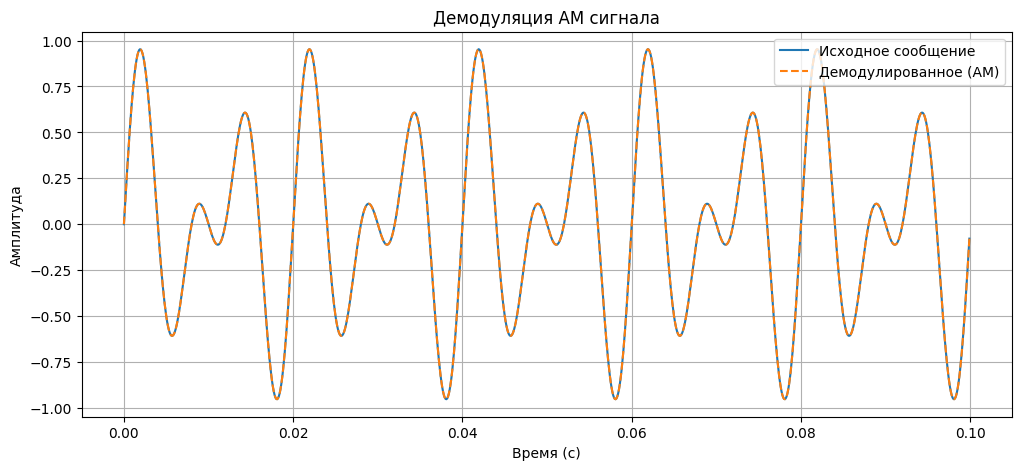

Среднеквадратичная ошибка АМ: 0.000000


In [12]:
# Аналитический сигнал для АМ
analytic_am = hilbert(s_am)
envelope = np.abs(analytic_am) # огибающая = 1 + m(t)

# Убираем постоянную составляющую
demod_am = envelope - 1

# Нормализуем сигнал
demod_am = demod_am/a_am

# Сравнение с исходным
plt.figure()
plt.plot(t, m_t, label='Исходное сообщение')
plt.plot(t, demod_am, '--', label='Демодулированное (АМ)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Демодуляция АМ сигнала')
plt.legend()
plt.grid(True)
plt.show()

error_am = np.std(m_t - demod_am)
print(f'Среднеквадратичная ошибка АМ: {error_am:.6f}')

Вычислите среднеквадратичную ошибку между исходным и восстановленным сообщением с помощью функции `np.std`.

### 3.2. Демодуляция ФМ сигнала

Для ФМ информация заключена в отклонении фазы от линейного тренда. Используем аналитический сигнал и выделим мгновенную фазу.

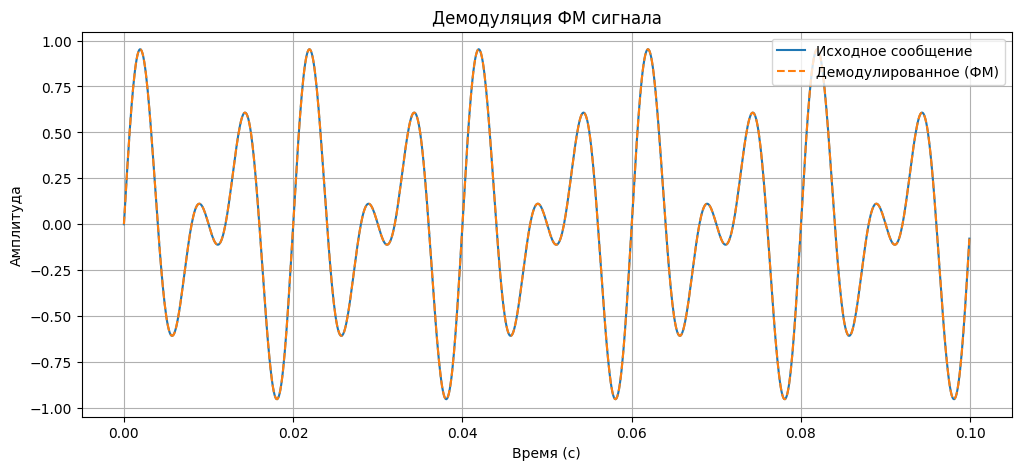

In [13]:
# Аналитический сигнал для ФМ
analytic_pm = hilbert(s_pm)
inst_phase = np.unwrap(np.angle(analytic_pm))   # развернутая фаза

# Убираем линейную составляющую (фаза несущей)
phase_no_carrier = inst_phase - 2 * np.pi * fc * t

# Убираем постоянную составляющую (может появиться в общем случае при наличии шумов, искажений и т. п.)
demod_pm = phase_no_carrier - np.mean(phase_no_carrier)

# Нормализуем сигнал
demod_pm = demod_pm / beta_pm

# Сравнение с исходным
plt.figure()
plt.plot(t, m_t, label='Исходное сообщение')
plt.plot(t, demod_pm, '--', label='Демодулированное (ФМ)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Демодуляция ФМ сигнала')
plt.legend()
plt.grid(True)
plt.show()

**Вопрос:** Почему важно использовать `np.unwrap` для фазы?

np.angle возвращает фазу в [-π, π] При пересечении границы этого диапазона возникают искусственные скачки на 2π. np.unwrap обнаруживает эти скачки и устраняет их, добавляя или вычитая 2π

## Часть 4. Устойчивость к шумам

В этой части мы работаем с реальным аудиофайлом. Для примера WAV-файл расположен в том же репозитории, что и ноутбук по адресу `data/sample-3s.wav`, но его надо загрузить в Google Colab.

### 4.1. Загрузка аудио (или генерация тестового сигнала)

In [14]:
# Загружаем файл и сохраняем под именем audio.wav
!wget -O audio.wav "https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/sample-3s.wav"

--2026-06-07 15:49:28--  https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/sample-3s.wav
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/sample-3s.wav [following]
--2026-06-07 15:49:28--  https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/sample-3s.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 563756 (551K) [audio/wav]
Saving to: ‘audio.wav’

audio.wav           100%[===================>] 550.54K  --.-KB/s    in 0.04s   

2026-06-07 15:49:28 (12.0 MB/s) - ‘audio.wav’ saved [563756/563756]



In [15]:
fs_audio, melody_stereo = wavfile.read('audio.wav') # читаем wav-файл в массив numpy, в файл записан стереосигнал, поэтому melody_stereo будет содержать две дорожки (левую и правую)

melody = melody_stereo[:,0] # переходим к моносигналу, беря только одну из двух дорожек
melody = melody / np.max(np.abs(melody)) # нормализуем сигнал, чтобы корректно работала амплитудная модуляция

t_audio = np.linspace(0, melody.shape[0]/fs_audio, melody.shape[0], endpoint=False) # для визуализации создаём также массив временных отсчётов

print(f"Частота дискретизации: {fs_audio} Гц")
print(f"Длина временного ряда: {len(melody)}")
print(f"Тип данных: {melody.dtype}")

print("Исходное аудио:")
display(Audio(melody, rate=fs_audio))

Частота дискретизации: 44100 Гц
Длина временного ряда: 140928
Тип данных: float64
Исходное аудио:


Постройте графики самого сигнала и его спектра. Подпишите оси.

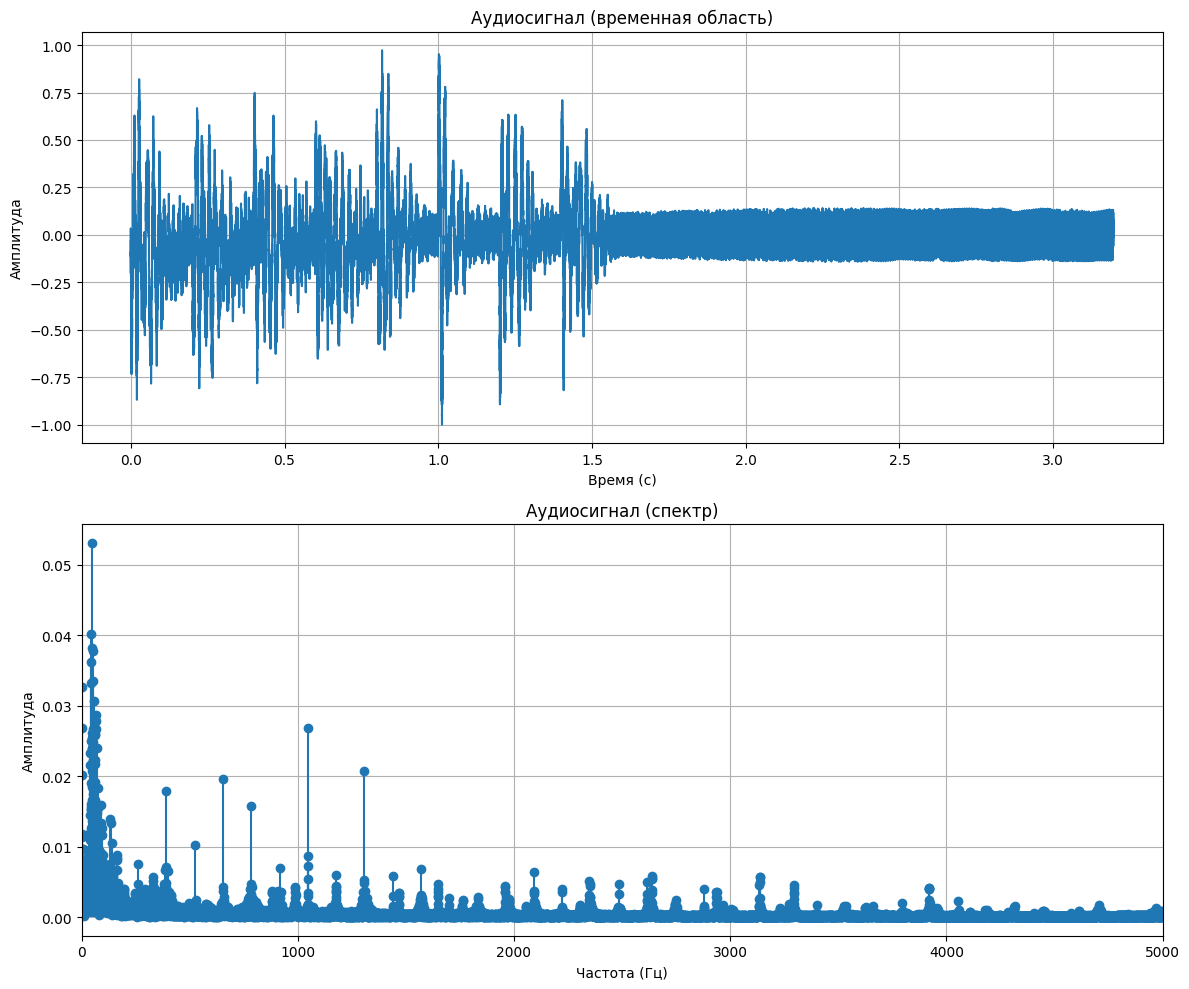

In [16]:
plt.figure(figsize=(12, 10))

plt.subplot(2, 1, 1)
plt.plot(t_audio, melody)
plt.title('Аудиосигнал (временная область)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.subplot(2, 1, 2)
N = len(melody)
X = np.fft.fft(melody)
freq = np.fft.fftfreq(N, 1/fs_audio)
half = N // 2
freq_pos = freq[:half]
amplitude = np.abs(X[:half]) / half
plt.stem(freq_pos, amplitude, basefmt=" ")
plt.title('Аудиосигнал (спектр)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.xlim(0, 5000)

plt.tight_layout()
plt.show()

**Вопрос:** До каких частот наблюдаются заметные пики в сигнале? Подумайте, какую частоту несущей можно выбрать при частоте дискретизации 44,1 кГц, чтобы эти пики не потерять. Как на это влияет выбор индекса модуляции ФМ-сигнала?

При одинаковой амплитуде шума ФМ демонстрирует лучшую устойчивость: искажения слышны при более высоких уровнях шума. Это связано с тем, что амплитудный шум напрямую влияет на огибающую в АМ, но не влияет на фазу в ФМ.

### 4.2. Подготовка к модуляции (интерполяция)

Выберите частоту несущей в соответствии с ответом на предыдущий вопрос (если восстановленный сигнал будет сильно зашумлён, попробуйте другие значения).

In [17]:
fc_high = 5000 # несущая 5 кГц
Ac = 1

print(f'несущая частота: {fc_high} Гц')
print(f'При fs = {fs_audio} Гц максимальная частота сигнала не должна превышать {fs_audio/2} Гц')
print(f'5 кГц < {fs_audio/2} Гц, условие Найквиста выполняется')

несущая частота: 5000 Гц
При fs = 44100 Гц максимальная частота сигнала не должна превышать 22050.0 Гц
5 кГц < 22050.0 Гц, условие Найквиста выполняется


### 4.3. Модуляция аудиосигнала
Сгенерируйте модулированные сигналы. Индекс модуляции для ФМ-сигнала выберите так, чтобы несильно портить модулируемый сигнал.

In [18]:
# АМ
a_am = 0.2
s_am_audio = Ac * (1 + a_am * melody) * np.cos(2 * np.pi * fc_high * t_audio)

# ФМ
beta_pm_audio = 2
s_pm_audio = Ac * np.cos(2 * np.pi * fc_high * t_audio + beta_pm_audio * melody)

### 4.4. Добавление шумов

**Амплитудный шум:** мультипликативный гауссов шум.

In [19]:
noise_amp = 0.1 * np.random.randn(len(t_audio))
s_am_noisy = s_am_audio * (1 + noise_amp)
s_pm_noisy = s_pm_audio * (1 + noise_amp)

### 4.5. Демодуляция сигналов

**Демодуляция АМ:**

Используйте преобразование Гильберта, чтобы демодулировать АМ-сигнал без шума, убедитесь, что качество звука изменилось незначительно.

In [20]:
analytic_am_audio = hilbert(s_am_audio)
envelope_am = np.abs(analytic_am_audio)
demod_am_audio = (envelope_am - 1) / a_am

print("Демодулированный АМ сигнал (без шума):")
display(Audio(demod_am_audio, rate=fs_audio))

Демодулированный АМ сигнал (без шума):


Демодулируйте зашумлёный АМ-сигнал.

In [21]:
analytic_am_noisy = hilbert(s_am_noisy)
envelope_am_noisy = np.abs(analytic_am_noisy)
demod_am_noisy = (envelope_am_noisy - 1) / a_am

print("Демодулированный АМ сигнал (с шумом):")
display(Audio(demod_am_noisy, rate=fs_audio))

Демодулированный АМ сигнал (с шумом):


**Вопросы:**
* Изменилось ли качество звука?
* Зафиксируйте $a_{AM}=0{,}2$. Попробуйте поменять амплитуду шума. При каких значениях амплитуды вы слышите заметную разницу с оригиналом?
* Зафиксируйте амплитуду шума равную 0,01. Попробуйте поменять $a_{AM}$, при каких амплитудах модуляции начинаются заметные искажения? Сделайте вывод о соотношении $a_{AM}$ и допустимых уровнях шума.

{Введите ваш ответ здесь}

**Демодуляция ФМ:**

Используйте метод аналитического сигнала для демодуляции ФМ-сигнала. Убедитесь, что качество звука изменилось незначительно.

In [22]:
analytic_pm_audio = hilbert(s_pm_audio)
inst_phase = np.unwrap(np.angle(analytic_pm_audio))
phase_no_carrier = inst_phase - 2 * np.pi * fc_high * t_audio
demod_pm_audio = (phase_no_carrier - np.mean(phase_no_carrier)) / beta_pm_audio

print("Демодулированный ФМ сигнал (без шума):")
display(Audio(demod_pm_audio, rate=fs_audio))

Демодулированный ФМ сигнал (без шума):


Демодулируйте зашумлёный ФМ-сигнал.

In [23]:
analytic_pm_noisy = hilbert(s_pm_noisy)
inst_phase_noisy = np.unwrap(np.angle(analytic_pm_noisy))
phase_no_carrier_noisy = inst_phase_noisy - 2 * np.pi * fc_high * t_audio
demod_pm_noisy = (phase_no_carrier_noisy - np.mean(phase_no_carrier_noisy)) / beta_pm_audio

print("Демодулированный ФМ сигнал (с шумом):")
display(Audio(demod_pm_noisy, rate=fs_audio))

Демодулированный ФМ сигнал (с шумом):


**Вопросы:**
* Изменилось ли качество звука?
* Зафиксируйте $\beta=2$. Попробуйте поменять амплитуду шума. При каких значениях амплитуды вы слышите заметную разницу с оригиналом?
* Зафиксируйте амплитуду шума равную 0,1. Попробуйте поменять $\beta$. Как субъективная величина искажений зависит от $\beta$?

{Введите ваш ответ здесь}

### 4.6. Сравнение спектров

Выберите значение амплитуды шума и величин $a_{AM}$ и $\beta$ так, чтобы искажения были заметны, но не велики. Постройте спектры исходного сигнала и сигналов, восстановлённых из зашумлённых АМ и ФМ-сигналов.

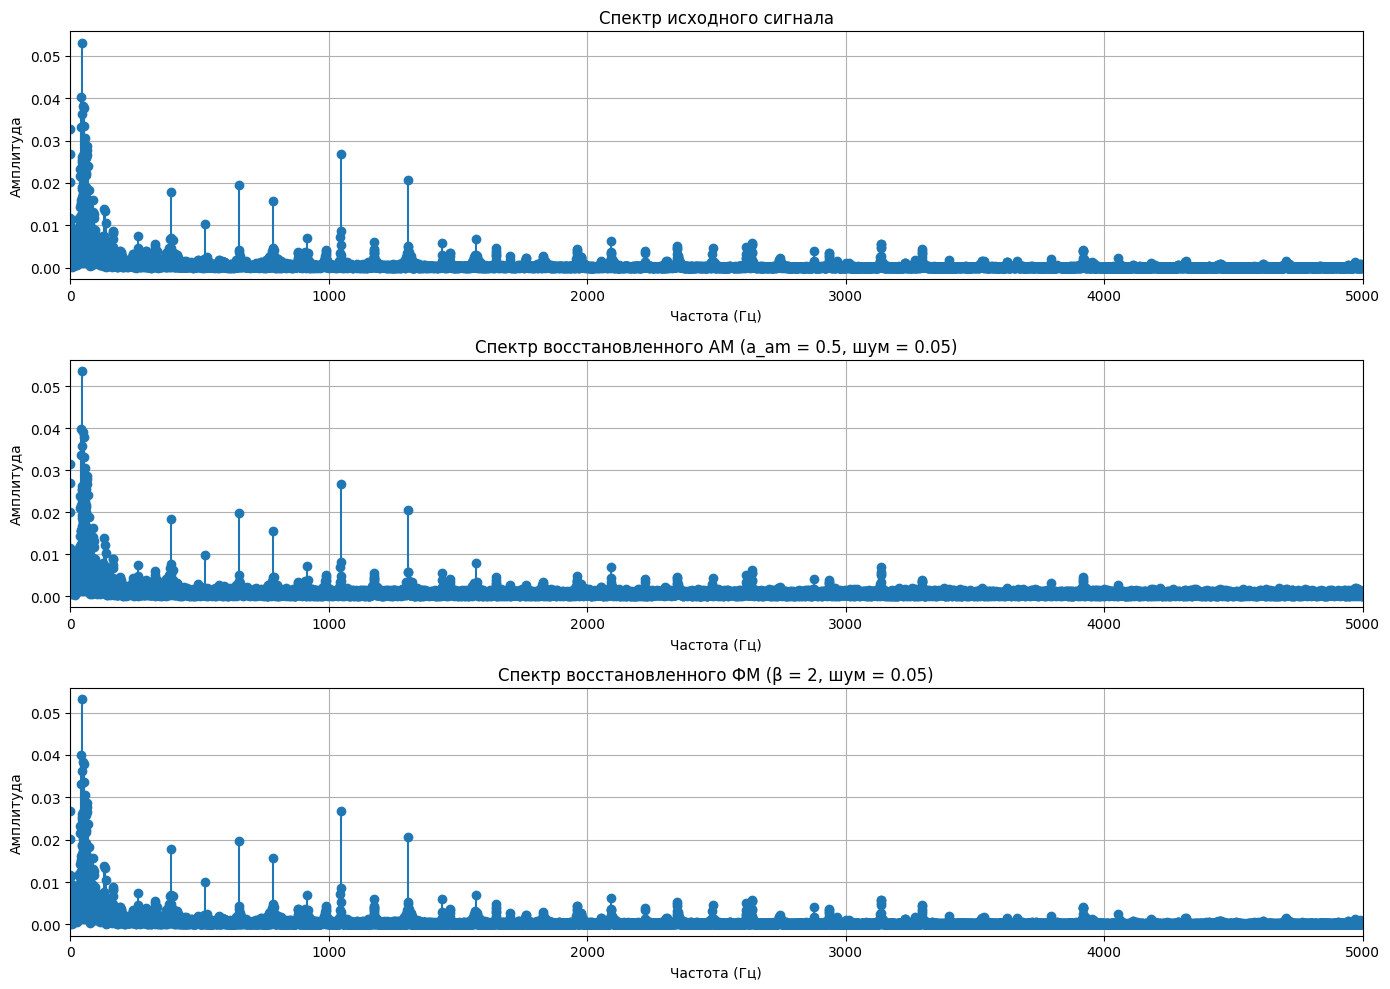

In [24]:
# Выбираем параметры, при которых искажения заметны, но не велики
noise_amp_test = 0.05
a_am_test = 0.5
beta_pm_test = 2

# Создаём сигналы с шумом
noise_test = noise_amp_test * np.random.randn(len(t_audio))
s_am_test = Ac * (1 + a_am_test * melody) * np.cos(2*np.pi*fc_high*t_audio)
s_am_test_noisy = s_am_test * (1 + noise_test)

s_pm_test = Ac * np.cos(2*np.pi*fc_high*t_audio + beta_pm_test * melody)
s_pm_test_noisy = s_pm_test * (1 + noise_test)

# Демодуляция
demod_am_test = (np.abs(hilbert(s_am_test_noisy)) - 1) / a_am_test

analytic_pm_test = hilbert(s_pm_test_noisy)
phase_test = np.unwrap(np.angle(analytic_pm_test))
phase_no_carrier_test = phase_test - 2*np.pi*fc_high*t_audio
demod_pm_test = (phase_no_carrier_test - np.mean(phase_no_carrier_test)) / beta_pm_test

# Построение спектров
plt.figure(figsize=(14, 10))

N = len(melody)
X_orig = np.fft.fft(melody)
freq = np.fft.fftfreq(N, 1/fs_audio)
half = N // 2
freq_pos = freq[:half]
amp_orig = np.abs(X_orig[:half]) / half

plt.subplot(3, 1, 1)
plt.stem(freq_pos, amp_orig, basefmt=" ")
plt.title('Спектр исходного сигнала')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.xlim(0, 5000)

X_am = np.fft.fft(demod_am_test)
amp_am = np.abs(X_am[:half]) / half
plt.subplot(3, 1, 2)
plt.stem(freq_pos, amp_am, basefmt=" ")
plt.title(f'Спектр восстановленного АМ (a_am = {a_am_test}, шум = {noise_amp_test})')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.xlim(0, 5000)

X_pm = np.fft.fft(demod_pm_test)
amp_pm = np.abs(X_pm[:half]) / half
plt.subplot(3, 1, 3)
plt.stem(freq_pos, amp_pm, basefmt=" ")
plt.title(f'Спектр восстановленного ФМ (β = {beta_pm_test}, шум = {noise_amp_test})')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.xlim(0, 5000)

plt.tight_layout()
plt.show()

**Вопрос:**
* Заметны ли визуально искажения спектров для случаев АМ и ФМ?

{Введите ваш ответ здесь}

Постройте спектры АМ и ФМ сигналов. Зафиксируйте $\beta=2$, подберите $a_{AM}$ так, чтобы амплитуды гармоник в обоих случаях были сравнимы по величине.

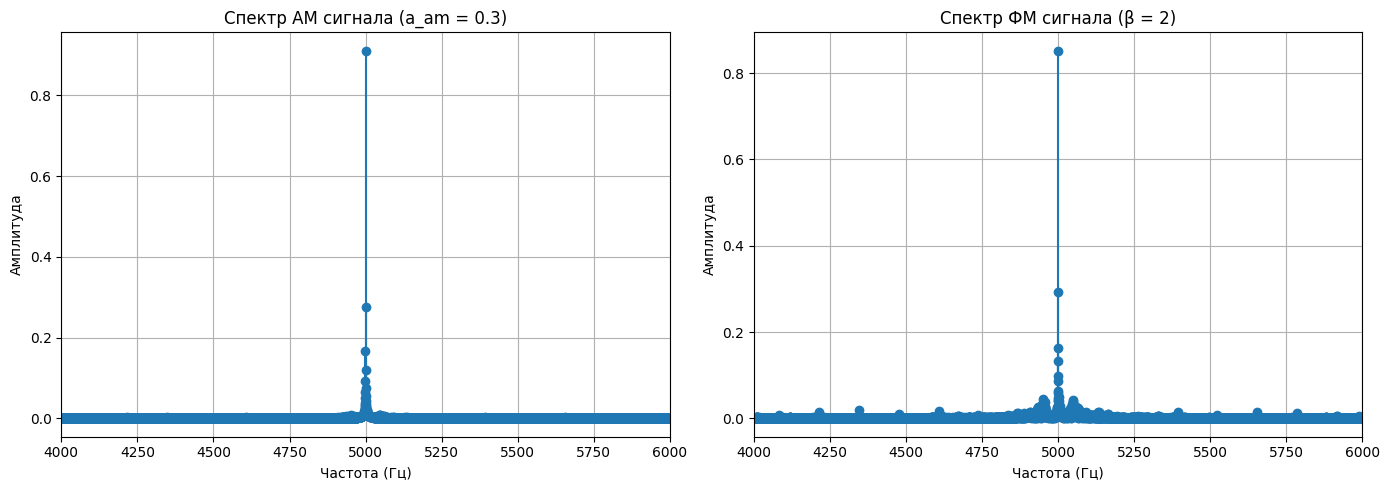

In [25]:
# Подбираем a_am так, чтобы амплитуды были сравнимы с ФМ при β=2
a_am_compare = 0.3
beta_compare = 2

s_am_compare = Ac * (1 + a_am_compare * melody) * np.cos(2*np.pi*fc_high*t_audio)
s_pm_compare = Ac * np.cos(2*np.pi*fc_high*t_audio + beta_compare * melody)

plt.figure(figsize=(14, 5))

N = len(s_am_compare)
X_am_c = np.fft.fft(s_am_compare)
X_pm_c = np.fft.fft(s_pm_compare)
freq = np.fft.fftfreq(N, 1/fs_audio)
half = N // 2
freq_pos = freq[:half]
amp_am_c = np.abs(X_am_c[:half]) / half
amp_pm_c = np.abs(X_pm_c[:half]) / half

plt.subplot(1, 2, 1)
plt.stem(freq_pos, amp_am_c, basefmt=" ")
plt.title(f'Спектр АМ сигнала (a_am = {a_am_compare})')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.xlim(fc_high-1000, fc_high+1000)

plt.subplot(1, 2, 2)
plt.stem(freq_pos, amp_pm_c, basefmt=" ")
plt.title(f'Спектр ФМ сигнала (β = {beta_compare})')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.xlim(fc_high-1000, fc_high+1000)

plt.tight_layout()
plt.show()

**Вопрос:**
* При какой амплитуде шума в этом случае вы слышите заметные искажения АМ сигнала? А ФМ сигнала? Сделайте вывод.

{Введите ваш ответ здесь}